In [85]:
import os
import sys
mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [86]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [96]:
import torch
from torch.distributions import constraints
import lib.distributions as distr
import matplotlib.pyplot as plt
from lib.distributions.utils.visualization import plot_mgvm_distr_1d, plot_mgvm_distr_2d
from sklearn.datasets import make_spd_matrix

In [97]:
#phi = torch.randn(1,2)
#w = torch.randn(4,4)
theta = torch.tensor([0,0])
A = torch.randn(4,4)
#W = A @ A.T + 4 * torch.eye(4)
W = torch.eye(4)
theta_batch = theta.repeat(3,1)
W_batch = W.repeat(3,1,1)

iscale = torch.tensor([torch.pi,torch.pi/4])
iscale_batch = iscale.repeat(3,1)
iloc = torch.tensor([0.0,0.0])
iloc_batch = iloc.repeat(3,1)

print(W_batch)
print(torch.linalg.eigvals(W_batch).real)
print(torch.min(torch.linalg.eigvals(W_batch).real,dim=1).values.unsqueeze(1))

tensor([[[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]]])
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor([[1.],
        [1.],
        [1.]])


In [98]:
mg_vm = distr.MGVonMises(loc=iloc_batch, scale=iscale_batch, precision=W_batch)
mg_vm.rsample(iloc_batch.shape)


tensor([[5.8073, 2.9951],
        [6.1223, 6.0763],
        [5.7026, 1.9628]])

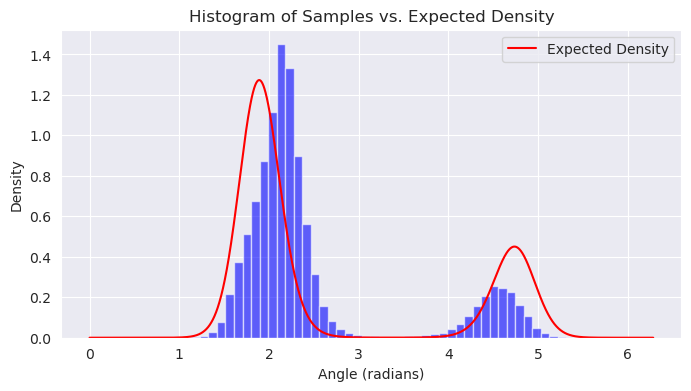

Sample Mean: 2.5028, Expected Mean: 3.1416
Sample Variance: 0.8793


In [104]:
loc = torch.tensor([torch.pi])
scale = torch.tensor([3.0])
precision = 10 * torch.tensor(make_spd_matrix(n_dim=2)).type(torch.float32)
#precision = torch.eye(2)

plot_mgvm_distr_1d(loc, scale, precision, num_samples=100000)


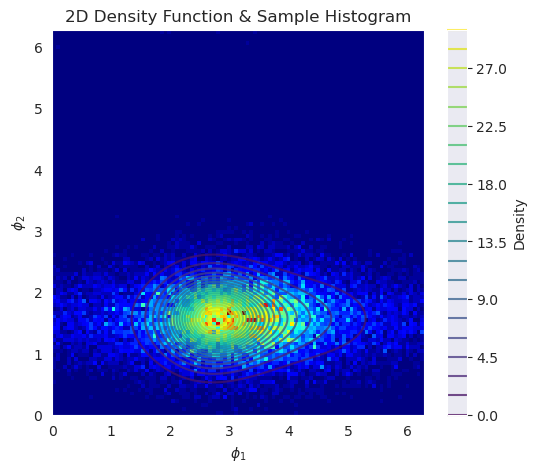

In [100]:
# Define test parameters
loc = torch.tensor([torch.pi, torch.pi/2])
scale = torch.tensor([1.1,5.1])
#precision = 10 * torch.tensor(make_spd_matrix(n_dim=4)).type(torch.float32)
precision = 4*torch.eye(4) + 2*torch.tensor([[0.0,0.0,0.5,0.5],[0.0,0.0,0.0,0.0],[0.5,0.0,0.0,0.0],[.5,0.0,0.0,0.0]])

plot_mgvm_distr_2d(loc=loc, scale=scale, precision=precision)


In [101]:
loc = torch.tensor([torch.pi, torch.pi/2, torch.pi/4])
scale = torch.tensor([1.0,10.0,1.0])
q = torch.distributions.VonMises(iloc_batch, iscale_batch)
sample = q.sample((1,)).squeeze(0)
print(sample)
print((1,))
print(iloc_batch.shape)

tensor([[-0.1083,  2.2126],
        [ 1.5320,  2.0662],
        [ 1.1251,  0.4593]])
(1,)
torch.Size([3, 2])
